# Loan Default Prediction — Modelling

This notebook builds and evaluates three classification models in order of 
complexity: Logistic Regression (baseline), Random Forest, and XGBoost.
Processed data is loaded from `data/processed/train_test_data.pkl` produced 
by `02_preprocessing.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Load preprocessed data
with open('../data/processed/train_test_data.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train default rate: {y_train.mean():.4f}")
print(f"y_test  default rate: {y_test.mean():.4f}")

X_train: (204277, 23)
X_test:  (51070, 23)
y_train default rate: 0.1161
y_test  default rate: 0.1161


## Model 1: Logistic Regression (Baseline)

Logistic Regression is a Generalised Linear Model (GLM) with a logit link 
function. Rather than minimising a sum of squared errors like OLS regression, 
it finds coefficients by **maximising the log-likelihood** of the observed 
binary outcomes, which is a direct application of Maximum Likelihood Estimation (MLE).

The model estimates the probability that a loan defaults:

    P(Default=1 | X) = 1 / (1 + exp(−Xβ))

where β are the coefficients estimated via MLE.

**Why `class_weight='balanced'`:** The training set has an 88.4/11.6 class 
split. Without adjustment, the model is incentivised to predict "no default" 
for everything and still achieve high accuracy. Setting `class_weight='balanced'` 
instructs sklearn to weight each class inversely proportional to its frequency, 
effectively penalising misclassification of the minority class (defaulters) more 
heavily. This is more principled than resampling methods like SMOTE because it 
operates on the loss function directly rather than artificially duplicating data.

**Why `max_iter=1000`:** The default of 100 iterations is sometimes insufficient 
for convergence on larger datasets. 1000 ensures the solver reaches the optimum.

In [2]:
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)
print("Logistic Regression training complete.")

Logistic Regression training complete.


In [3]:
# Predicted class labels (0 or 1)
lr_pred = lr_model.predict(X_test)

# Predicted probabilities of default (class 1)
# We need probabilities, not just labels, to compute ROC-AUC
lr_prob = lr_model.predict_proba(X_test)[:, 1]

## Evaluation — Logistic Regression

We evaluate using three complementary tools:

**1. ROC-AUC:** Measures how well the model separates defaulters from 
non-defaulters across all possible thresholds. AUC = 1.0 is perfect; 
AUC = 0.5 is random. This is our primary metric because it is unaffected 
by class imbalance.

The ROC curve directly visualises the Neyman-Pearson trade-off: at every 
threshold, we trade True Positive Rate (sensitivity / statistical power) 
against False Positive Rate (Type I error rate). A model pushed toward high 
sensitivity catches more defaulters but flags more good applicants as risky.

**2. Confusion Matrix:** Shows the four outcomes at the default 0.5 threshold:
- True Negatives (correctly predicted no default)
- False Positives (predicted default, actually fine — Type I error)  
- False Negatives (predicted no default, actually defaulted — Type II error)
- True Positives (correctly predicted default)

In a lending context, **False Negatives are more costly** — approving a loan 
that defaults causes direct financial loss. False Positives lose potential 
revenue but cause no loss.

**3. Classification Report:** Precision, Recall, and F1-score per class.

In [4]:
lr_auc = roc_auc_score(y_test, lr_prob)
print(f"Logistic Regression ROC-AUC: {lr_auc:.4f}")

Logistic Regression ROC-AUC: 0.7532


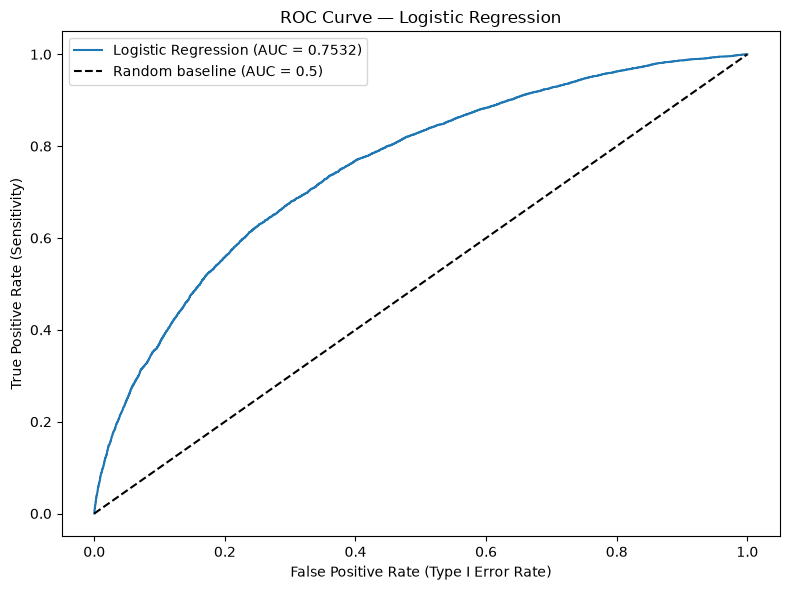

In [5]:
fpr, tpr, thresholds = roc_curve(y_test, lr_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {lr_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random baseline (AUC = 0.5)')
plt.xlabel('False Positive Rate (Type I Error Rate)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve — Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

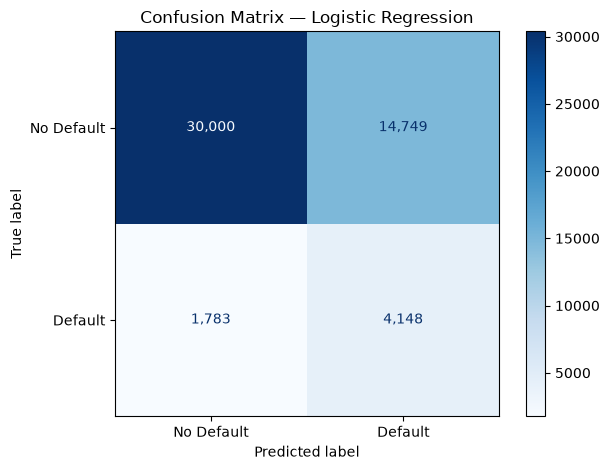

In [6]:
cm = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['No Default', 'Default'])
disp.plot(cmap='Blues')
for text in disp.text_.ravel():
    text.set_text(f'{int(float(text.get_text())):,}')
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

In [7]:
print("Classification Report — Logistic Regression")
print("=" * 50)
print(classification_report(y_test, lr_pred, 
                             target_names=['No Default', 'Default']))

Classification Report — Logistic Regression
              precision    recall  f1-score   support

  No Default       0.94      0.67      0.79     45139
     Default       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070



### Coefficient Interpretation

A key advantage of Logistic Regression over tree-based models is 
interpretability. Each coefficient β can be exponentiated to give an 
**odds ratio**: exp(β).

An odds ratio > 1 means that feature increases the odds of default; 
< 1 means it decreases the odds. This connects directly to how risk is 
communicated in real financial settings.

In [8]:
feature_names = X_train.columns.tolist()
coefficients = lr_model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Odds Ratio': np.exp(coefficients)
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))

                     Feature  Coefficient  Odds Ratio
                InterestRate     0.458402    1.581545
   EmploymentType_Unemployed     0.437870    1.549403
                  LoanAmount     0.287688    1.333341
    EmploymentType_Part-time     0.267532    1.306735
EmploymentType_Self-employed     0.245822    1.278672
              NumCreditLines     0.102550    1.107993
       Education_High School     0.071874    1.074520
                    DTIRatio     0.068981    1.071416
        LoanPurpose_Business     0.061379    1.063301
           LoanPurpose_Other    -0.011100    0.988962
       LoanPurpose_Education    -0.012543    0.987536
        MaritalStatus_Single    -0.051344    0.949951
                 CreditScore    -0.124957    0.882535
          Education_Master's    -0.140627    0.868813
                 HasMortgage    -0.164170    0.848598
               Education_PhD    -0.180183    0.835117
            LoanPurpose_Home    -0.187276    0.829215
       MaritalStatus_Married

### Logistic Regression — Results Interpretation

The Logistic Regression model achieved an **ROC-AUC score of 0.7532**, which means it can distinguish between defaulters and non-defaulters reasonably well. Since a score of 0.5 represents random guessing, this serves as a solid baseline for comparing more advanced models.

**Confusion Matrix (Threshold = 0.5):**
- **4,148 True Positives:** Defaulters correctly identified.
- **1,783 False Negatives:** Defaulters who were mistakenly predicted as safe borrowers.
- **14,749 False Positives:** Creditworthy applicants incorrectly classified as risky.
- **~30,000 True Negatives:** Non-defaulters correctly classified.

The model produces a relatively high number of false positives because `class_weight='balanced'` gives extra importance to detecting the minority class (defaulters). As a result, it achieves a good recall (0.70) but lower precision (0.22). In loan approval problems, this trade-off is often acceptable since approving a borrower who later defaults is generally more costly than rejecting someone who would have repaid the loan.

### Most Important Risk Factors

The variables with the strongest positive impact on the likelihood of default are:

- **Interest Rate (OR = 1.58):** The strongest predictor in the model. Borrowers with higher interest rates are more likely to default, which is consistent with the findings from the exploratory data analysis.
- **Employment Type – Unemployed (OR = 1.55):** Unemployed borrowers have about **55% higher odds** of default compared to full-time employees.
- **Loan Amount (OR = 1.33):** Larger loan amounts are associated with a higher risk of default.

### Factors Associated with Lower Default Risk

The variables that reduce the likelihood of default are:

- **Age (OR = 0.56):** Older borrowers are less likely to default.
- **Months Employed (OR = 0.71):** A longer employment history is associated with lower default risk.
- **Income (OR = 0.73):** Higher-income borrowers are generally more reliable in repaying loans.

Overall, the model's results closely match the patterns observed during the exploratory data analysis, suggesting that it has learned meaningful relationships from the data rather than random patterns.

*Next, we evaluate the Random Forest model, which can capture more complex, non-linear relationships between the features and the target variable.*